In [1]:
import pickle
import torch
import matplotlib
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

In [2]:
model_path = os.path.join(os.getcwd(), 'models')
train_dats = glob.glob(os.path.join(model_path, '*train_loss.dat'))
# val_dats = glob.glob(os.path.join(model_path, '*val_loss.dat'))

In [3]:
def parse_param(param_str):
    b_loc = 0
    e_loc = param_str.find('e')
    l_loc = param_str.find('l')
    r_loc = param_str.find('r')
    
    # Get param values
    batch = int(param_str[b_loc+1:e_loc])
    epoch = int(param_str[e_loc+1:l_loc])
    lr = float(param_str[r_loc+1:])
    
    # Get and conver loss weights to float tuple
    l_weights = np.array(param_str[l_loc+1:r_loc].split('-'))
    l_weights = tuple(map(float, l_weights))
    
    return batch, epoch, l_weights, lr

b32e20l0.1-20r0.0005


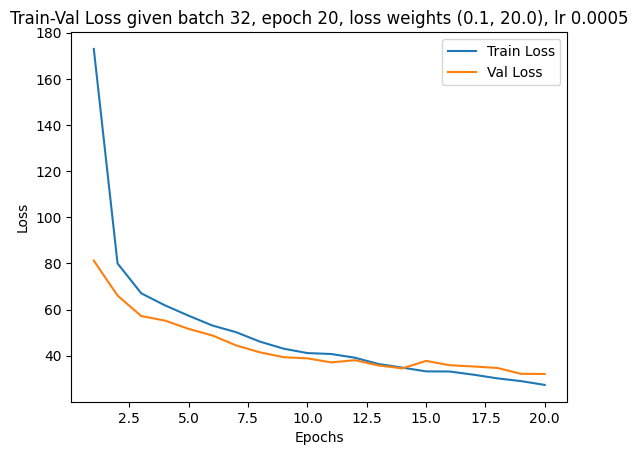

b32e20l0.5-25r0.0005


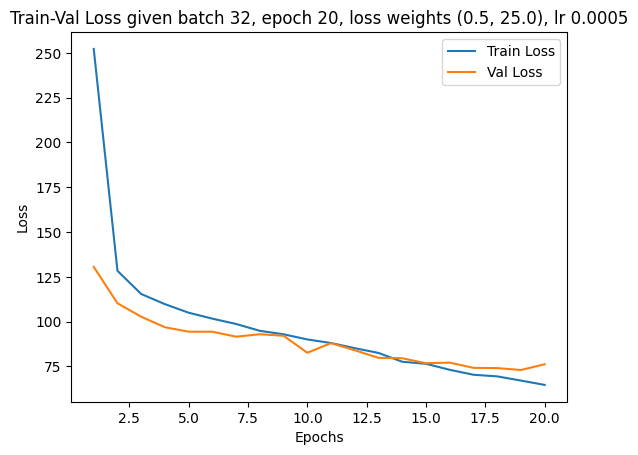

b32e20l1-10r0.0001


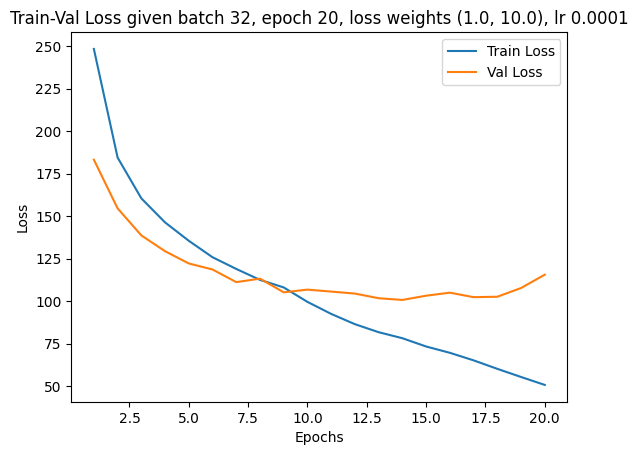

b32e20l0.3-20r0.0005


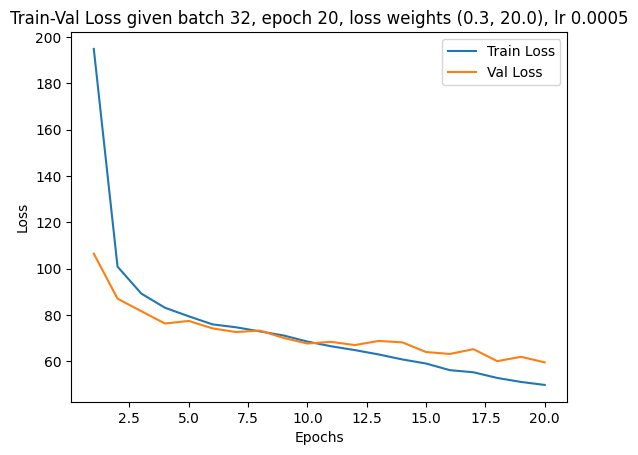

b10e20l1-10r0.0005


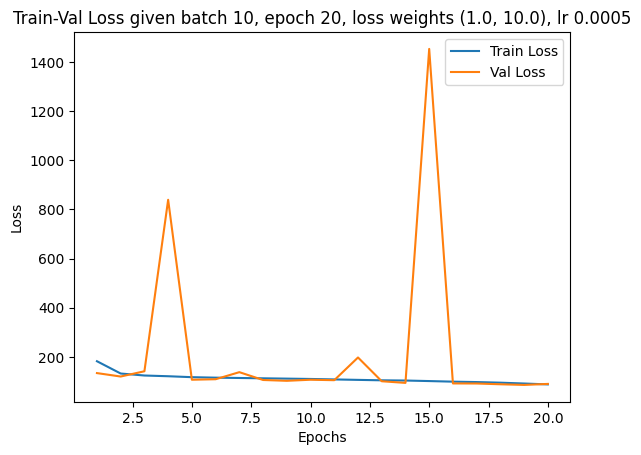

b10e20l0.5-25r0.0005


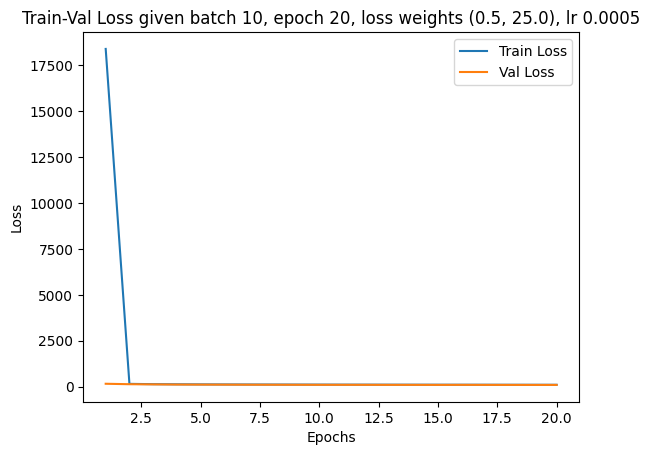

b10e20l0.1-20r0.0001


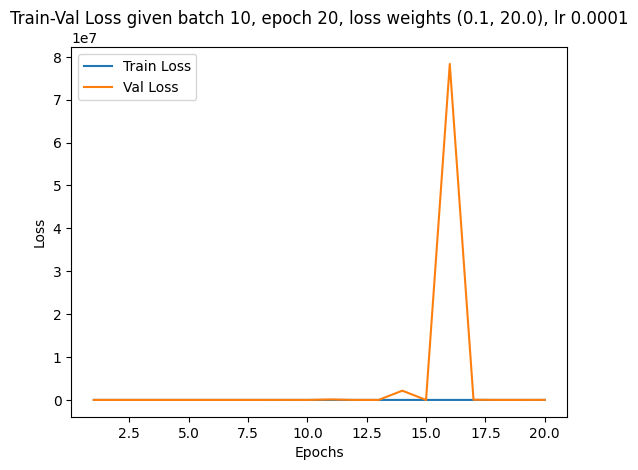

b32e20l0.1-20r0.0001


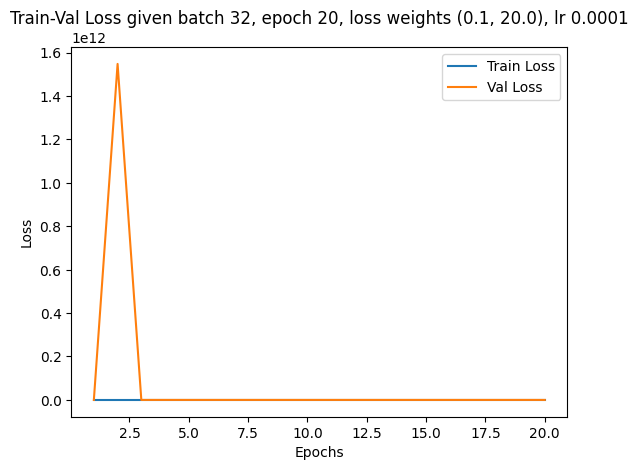

b32e20l0.5-25r0.0001


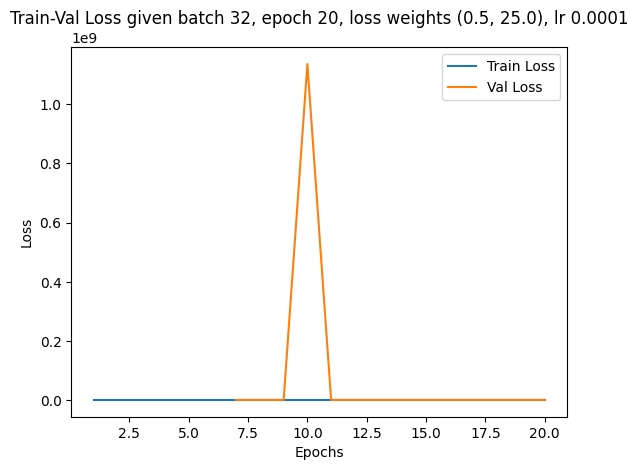

b10e20l0.3-20r0.0001


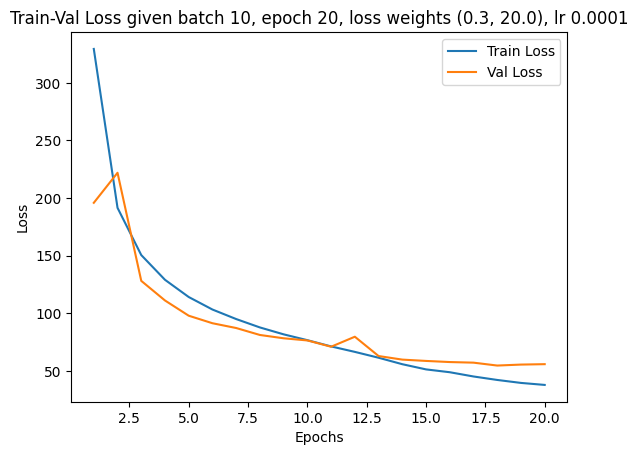

b32e20l0.3-20r0.0001


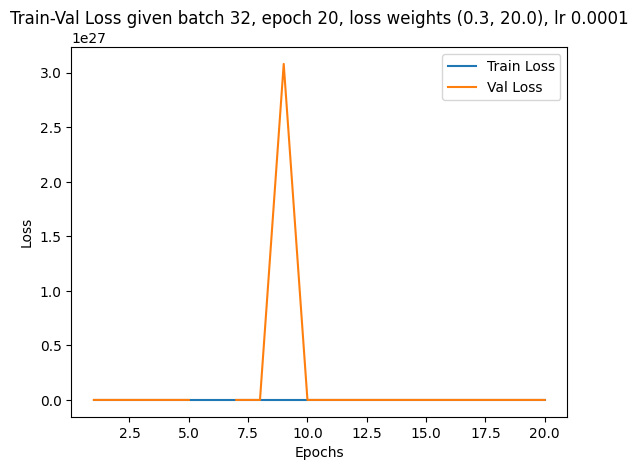

b10e20l0.3-20r0.0005


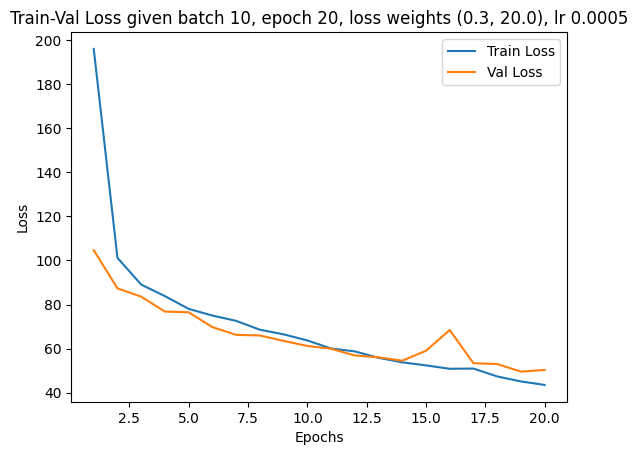

b10e20l0.1-20r0.0005


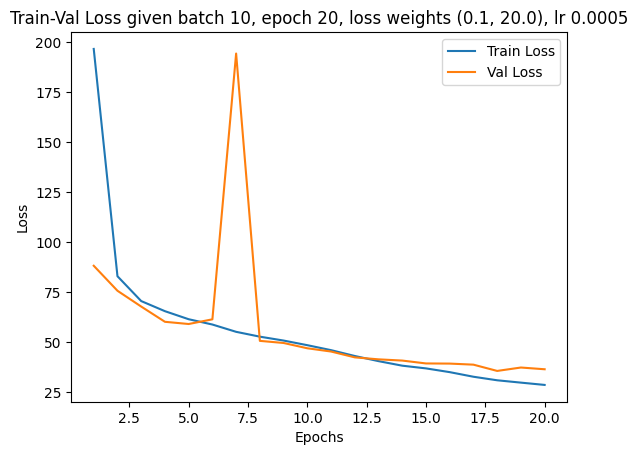

b10e20l1-10r0.0001


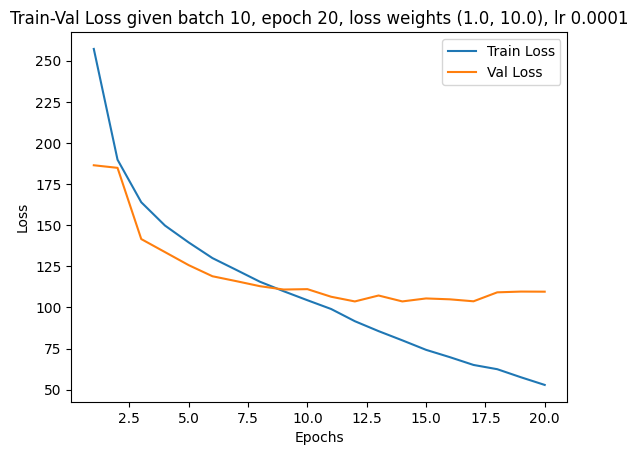

b10e20l0.5-25r0.0001


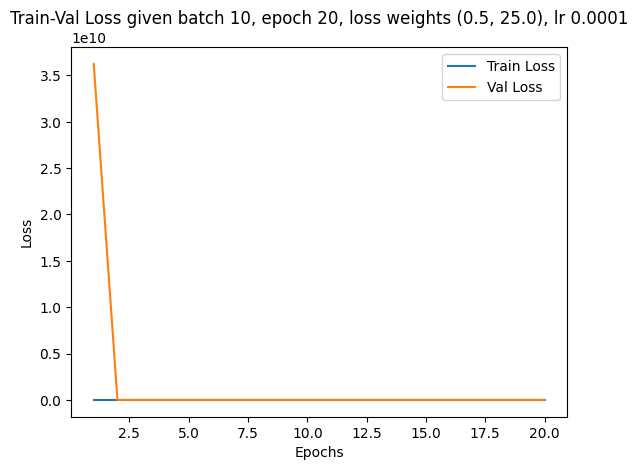

b32e20l1-10r0.0005


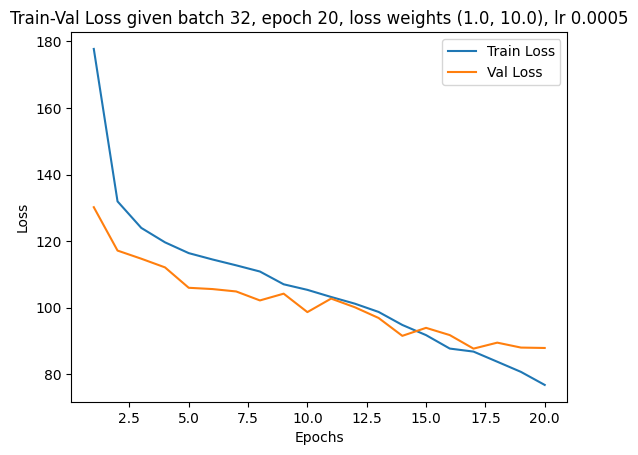

In [4]:
x = range(1, 21)
for train_file in train_dats:
    # Get param values
    params_raw = os.path.basename(train_file)[len('PosteriorYolo_'):-len('_train_loss.dat')]
    print(params_raw)
    batch, epoch, l_weights, lr = parse_param(params_raw)
    
    with open(train_file, 'rb') as file:
        train_losses = pickle.load(file)
        
    # Get Validation Losses
    val_file = train_file[:-len('_train_loss.dat')] + '_val_loss.dat'
    with open(val_file, 'rb') as file:
        val_losses = pickle.load(file)
    plt.plot(x, train_losses, label='Train Loss')
    plt.plot(x, val_losses, label='Val Loss')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Train-Val Loss given batch {batch}, epoch {epoch}, loss weights {l_weights}, lr {lr}')

    # Add a legend
    plt.legend()

    # Display the plot
    plt.show()

In [15]:
int('-1')

-1